In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import run_fair

import utils_ML

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

### Notebook for generating all sets of training, validation, test data for a NN emulator of FaIR

#### 1. ScenarioMIP for CMIP7
ScenarioMIP for CMIP7 consists of a set of scenarios that represent plausible future emissions pathways separated into sets by priority, either high (tier 1) and low (tier 2). Although all scenarios are requested to be run from 2025-2150, each scenario also has a long-term extension from 2150-2500; there is also a <i> historical </i> scenario using historical emissions data from 1750-2024 (FaIR specifically runs starting at 1750, while ESMs typically start in 1850). Only two extensions are part of tier 1: the <i>High</i> and <i> Very Low with Limited Overshoot. </i> For this work, we consider only emissions-driven scenarios, and the full list of scenarios is below.

<ol>
  <li> Tier 1</li>
  <ol>
    <li> High w/ Extension (H-ext) </li>
    <li> Medium (M) </li>
    <li> Medium-Low (ML) </li>
    <li> Low (L) </li>
    <li> Very Low with Limited Overshoot w/ Extension (VLLO-ext)</li>
    <li> Very Low after High Overshoot (VLHO)</li>
  </ol>
  <li> Tier 2</li>
  <ol>
    <li> High Overshoot w/ Extension (H-ext-OS) </li>
    <li> Medium w/ Extension (M-ext) </li>
    <li> Medium-Low w/ Extension (ML-ext) </li>
    <li> Low w/ Extension (L-ext) </li>
    <li> Very Low after High Overshoot w/ Extension (VLHO-ext) </li>
  </ol>
</ol>

We split these data as follows: (1) We use tier 1 scenarios to train our baseline emulator based on the assumption that all modeling centers will run these scenarios. (2) Also based on this assumption, we use tier 1 scenarios as the target of our Bayesian optimization to find the optimal parameter set for our theoretically optimal emulator training scenario. (3) We then test both emulators against the full set of tier 2 scenarios.

In [111]:
# Generate white noise
def sinusoidal_cycle(t, amplitude, frequency):
  """A long-period sinusoidal cycle."""
  return amplitude * np.sin(2 * np.pi * frequency * t)

start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
sigma, f_low, f_high = 61.540688, 0.040363, 0.115967
m_t = sinusoidal_cycle(np.arange(n_steps), 39.741618, 0.002614)

FS = 1

white_noise = np.random.randn(n_steps)
nyquist = 0.5 * FS
b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
w_t = signal.filtfilt(b, a, white_noise)
w_t -= np.mean(w_t)
w_t /= np.std(w_t)
noise_component = sigma * w_t

agents = ['CO2']
u_t = m_t + noise_component
emis_dict_opt = {'noise': run_fair.ensure_all_agents({'CO2': u_t}, n_steps)}
scenarios_opt = ['noise']
delT_dict_opt = run_fair.get_delT(emis_dict_opt, scenarios_opt, agents, MIP='noise')

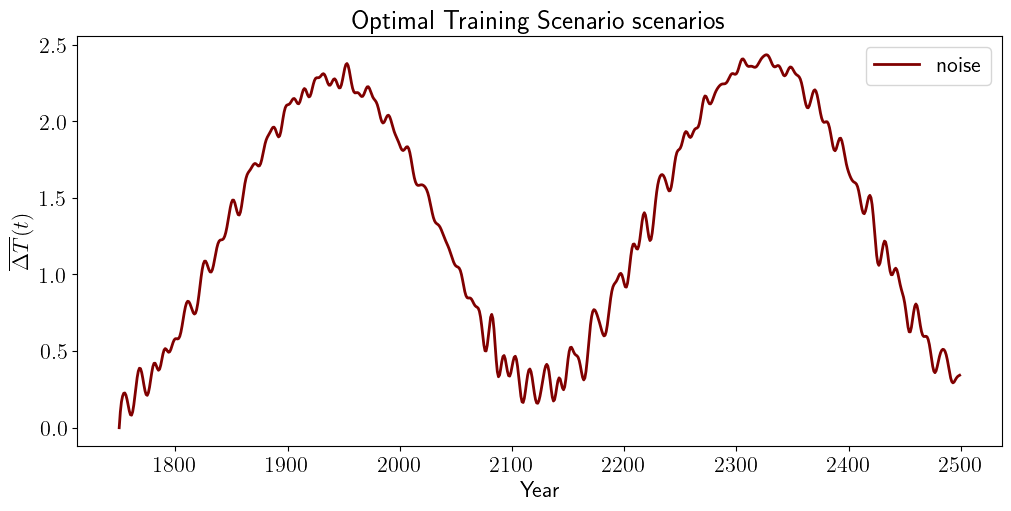

In [112]:
run_fair.plot_delT(delT_dict_opt, scenarios_opt, 'Optimal Training Scenario', MIP='noise')

In [9]:
# Generate tier 1 and tier 2 scenarios
agents = ['CO2']#,'CH4','N2O','Sulfur','BC']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())

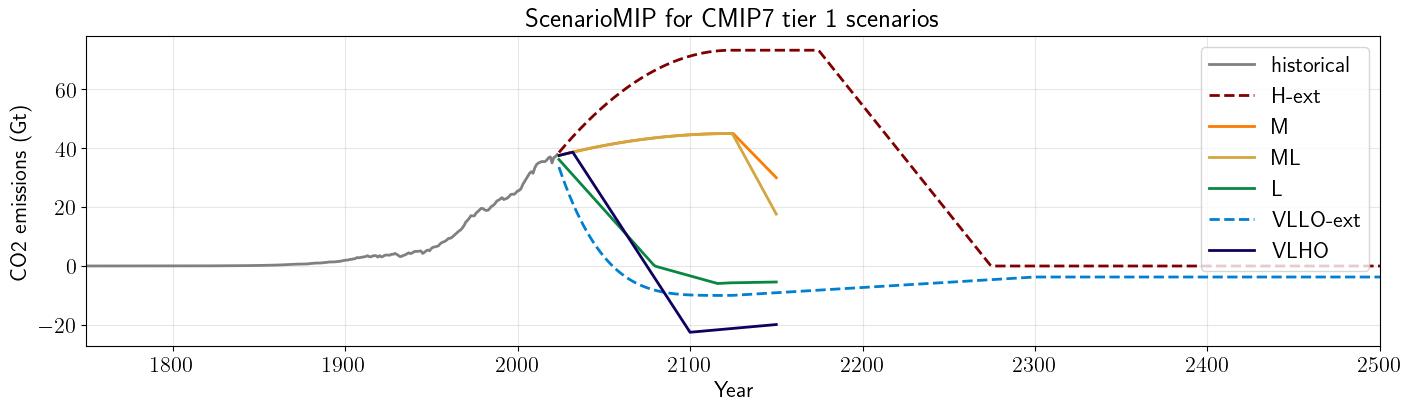

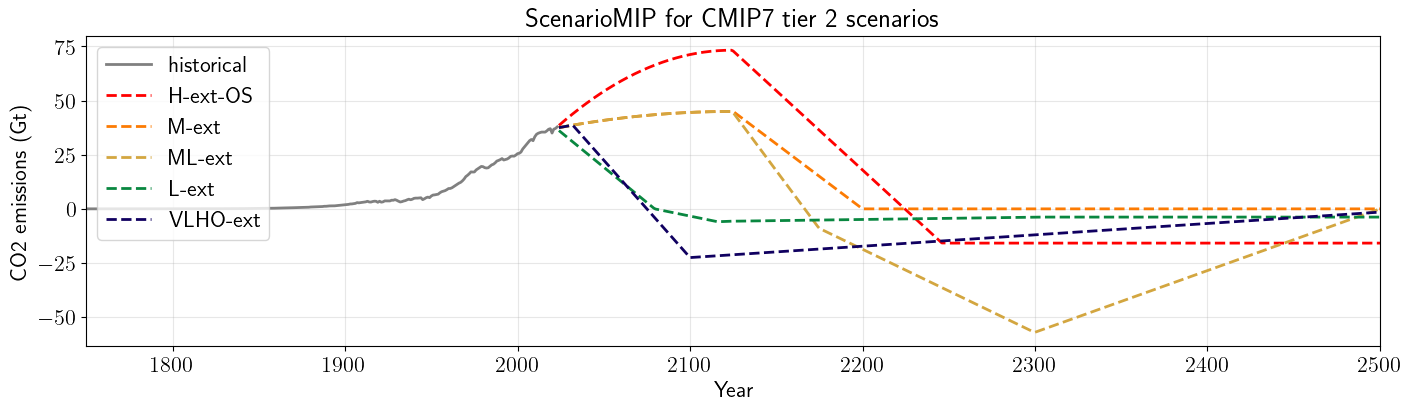

In [132]:
# Plot emissions scenarios (optional)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_tier1, agent, 'ScenarioMIP for CMIP7 tier 1')
run_fair.plot_emissions(emis_dict_tier2, agent, 'ScenarioMIP for CMIP7 tier 2')

In [109]:
# Run FaIR for each scenario to get temperature change
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')

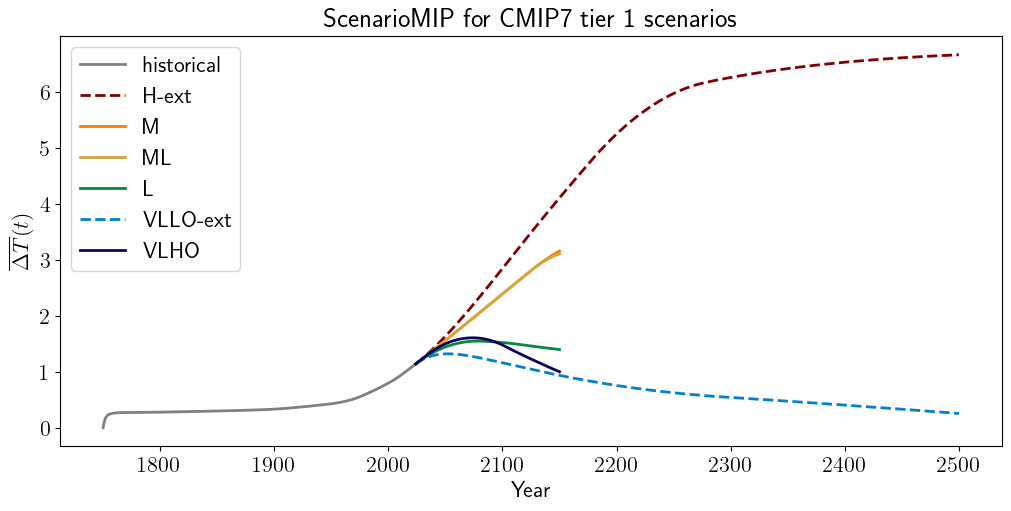

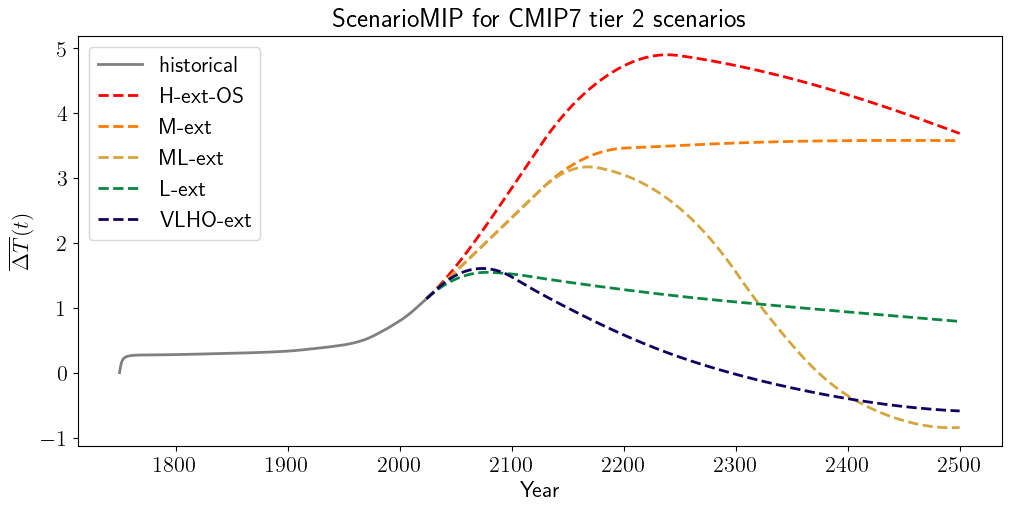

In [110]:
# Plot temperature change (optional)
run_fair.plot_delT(delT_dict_tier1, scenarios_tier1, 'ScenarioMIP for CMIP7 tier 1')
run_fair.plot_delT(delT_dict_tier2, scenarios_tier2, 'ScenarioMIP for CMIP7 tier 2')

In [23]:
series_tier1, series_tier2 = [], []
for scen in scenarios_tier1:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier1.append((emis_dict_tier1[scen], delT_dict_tier1[scen], needs_history))
for scen in scenarios_tier2:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier2.append((emis_dict_tier2[scen], delT_dict_tier2[scen], needs_history))

#error_dict_single, yhat_dict_single = utils_MLP.evaluate_trainsets_vs_tests_with_history(scenarios_tier1, series_tier1, scenarios_tier2, series_tier2, agents, n_lags=150, random_state=0)

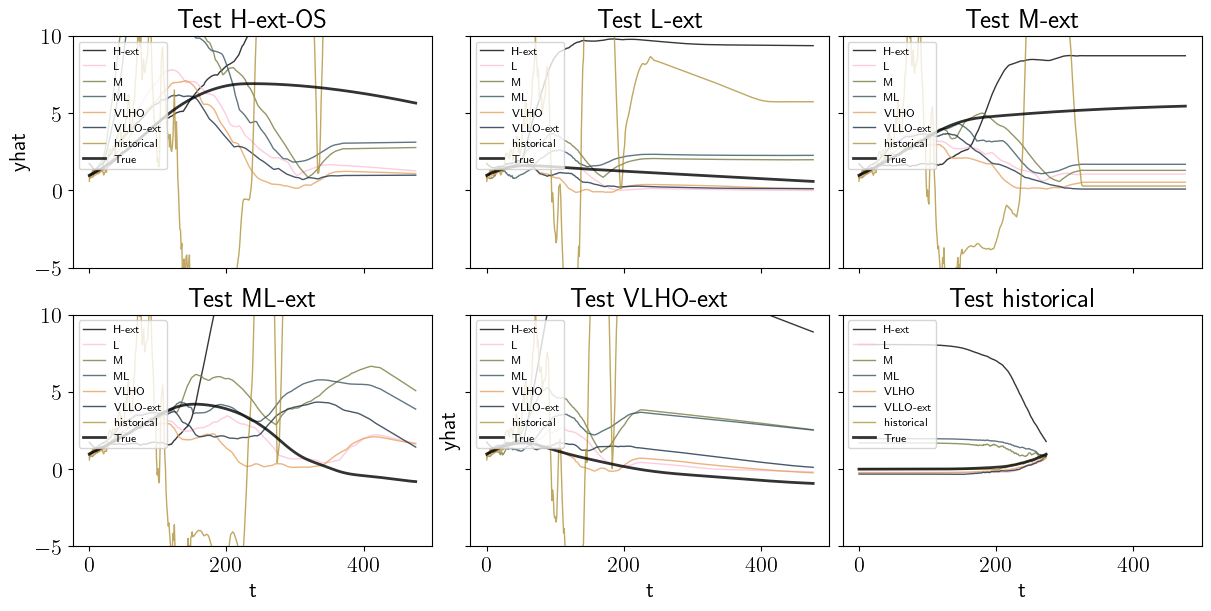

In [24]:
# Plot predictions (optional)
#utils_MLP.plot_yhats_grid(error_dict_single, yhat_dict_single, delT_dict_tier2)

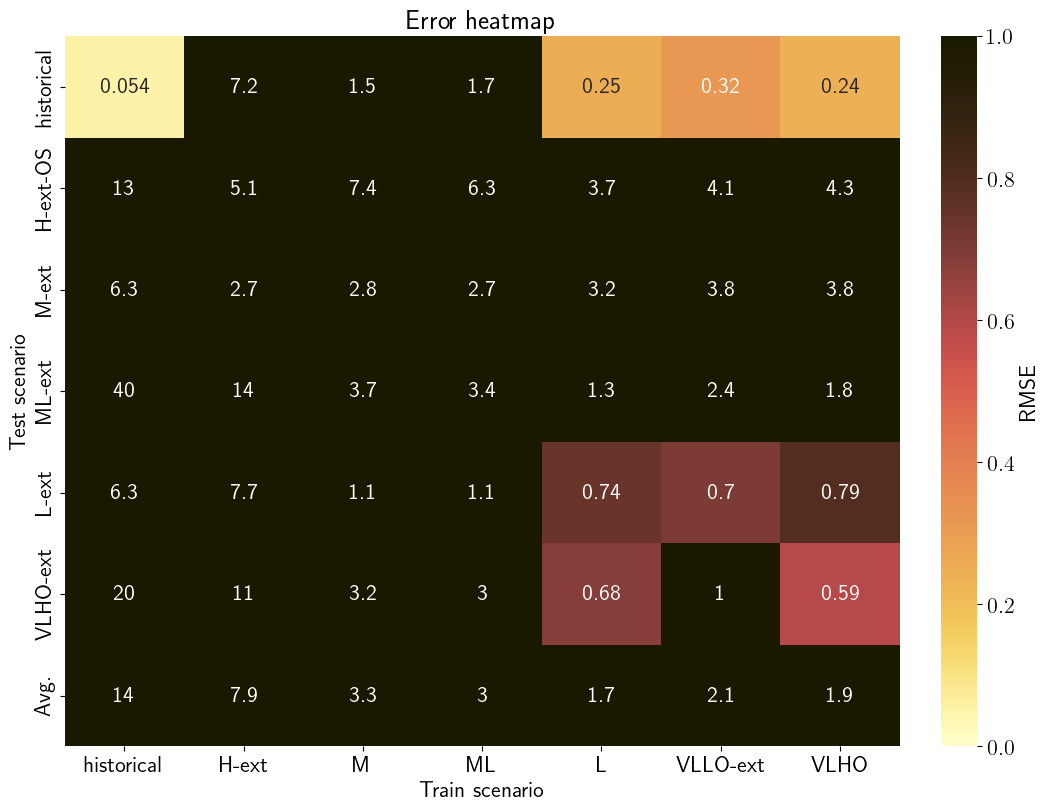

In [25]:
# Plot error heatmap (optional)
utils_MLP.plot_error_heatmap(error_dict_single, scenarios_tier1, scenarios_tier2)

Starting hyperparameter search...
  Testing dropout rate: 0.0, L2 penalty: 0.0
    -> Mean RMSE: 0.0556
  Testing dropout rate: 0.0, L2 penalty: 0.0001
    -> Mean RMSE: 0.0630
  Testing dropout rate: 0.0, L2 penalty: 0.001
    -> Mean RMSE: 0.0439
  Testing dropout rate: 0.0, L2 penalty: 0.01
    -> Mean RMSE: 0.0819
  Testing dropout rate: 0.1, L2 penalty: 0.0
    -> Mean RMSE: 0.1296
  Testing dropout rate: 0.1, L2 penalty: 0.0001
    -> Mean RMSE: 0.1685
  Testing dropout rate: 0.1, L2 penalty: 0.001
    -> Mean RMSE: 0.1354
  Testing dropout rate: 0.1, L2 penalty: 0.01
    -> Mean RMSE: 0.1324
  Testing dropout rate: 0.2, L2 penalty: 0.0
    -> Mean RMSE: 0.1663
  Testing dropout rate: 0.2, L2 penalty: 0.0001
    -> Mean RMSE: 0.2908
  Testing dropout rate: 0.2, L2 penalty: 0.001
    -> Mean RMSE: 0.2486
  Testing dropout rate: 0.2, L2 penalty: 0.01
    -> Mean RMSE: 0.3168
  Testing dropout rate: 0.4, L2 penalty: 0.0
    -> Mean RMSE: 0.3629
  Testing dropout rate: 0.4, L2 penalt

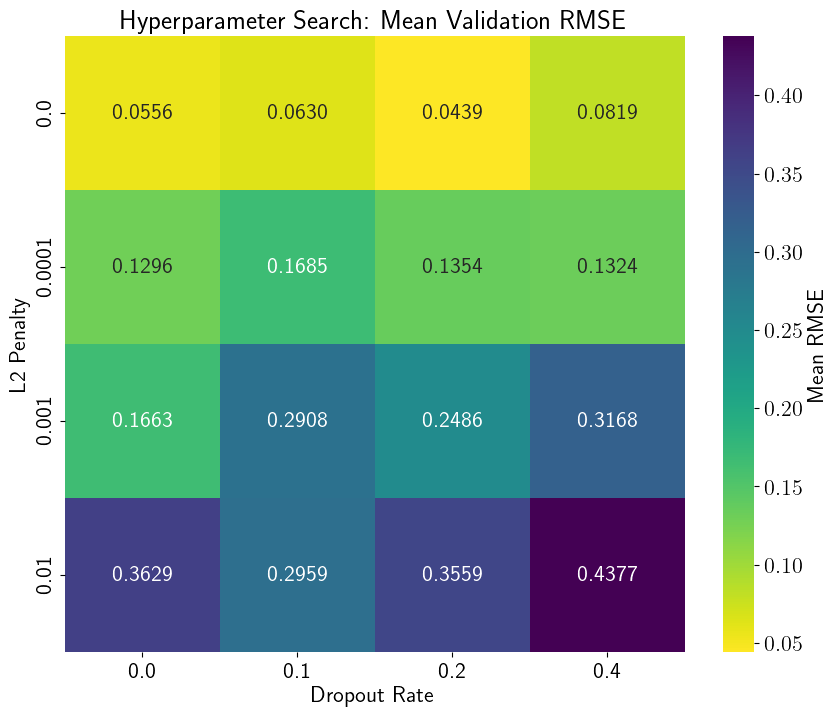

In [52]:
import seaborn as sns
# Assuming your 'evaluate_LSTM' function is in a file named utils_MLP.py
# from utils_MLP import evaluate_LSTM 

# --- 1. Define Hyperparameter Grids ---
# Define the different widths you want to test for each layer
dropouts = [0.0, 0.1, 0.2, 0.4]
l2_penalties = [0.0, 1e-4, 1e-3, 1e-2]

# Create an empty 2D array to store the error for each combination
# The rows will correspond to lstm_size, and columns to dense_size
error_grid_train = np.zeros((len(dropouts), len(l2_penalties)))
training_groups = {'All_CMIP7': scenarios_tier1.copy()}
# --- 2. Run the Evaluation Loop ---
print("Starting hyperparameter search...")

for i, dropout in enumerate(dropouts):
  for j, l2 in enumerate(l2_penalties):
    print(f"  Testing dropout rate: {dropout}, L2 penalty: {l2}")

    # --- Call your evaluation function with the current parameters ---
    # Replace with your actual data variables as needed.
    # This example uses the sample usage you provided.
    error_dict, _ = utils_MLP.evaluate_LSTM(
        train_scenarios=scenarios_tier1, 
        train_series=series_tier1,
        test_scenarios=scenarios_tier1, 
        test_series=series_tier1,
        agents=agents,
        training_groups=training_groups,
        n_lags=0,
        lstm_size=16,
        dense_size=32,
        dropout_rate=dropout,
        l2_penalty=l2
    )

    # --- 3. Process and Store the Results ---
    # The error_dict can have multiple training groups. We'll average the
    # errors across all test scenarios from all groups to get a single
    # representative error value for this parameter combination.
    all_errors = []
    for group_name in error_dict:
      for test_name in error_dict[group_name]:
        all_errors.append(error_dict[group_name][test_name])
    
    if not all_errors:
      print(f"    Warning: No errors were returned for this combination. Skipping.")
      mean_error = np.nan
    else:
      mean_error = np.mean(all_errors)
      print(f"    -> Mean RMSE: {mean_error:.4f}")

    error_grid_train[i, j] = mean_error

print("\nHyperparameter search complete.")

# --- 4. Plot the Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    error_grid_train,
    annot=True,         # Display the error values on the cells
    fmt=".4f",          # Format numbers to 4 decimal places
    cmap='viridis_r',   # Use a color map where lower is better (brighter)
    xticklabels=dropouts,
    yticklabels=l2_penalties,
    cbar_kws={'label': 'Mean RMSE'} # Label for the color bar
)

plt.xlabel("Dropout Rate")
plt.ylabel("L2 Penalty")
plt.title("Hyperparameter Search: Mean Validation RMSE")
plt.show()

Starting hyperparameter search...
  Testing dropout rate: 0.0, L2 penalty: 0.0
    -> Mean RMSE: 0.6725
  Testing dropout rate: 0.0, L2 penalty: 0.0001
    -> Mean RMSE: 0.7459
  Testing dropout rate: 0.0, L2 penalty: 0.001
    -> Mean RMSE: 0.6418
  Testing dropout rate: 0.0, L2 penalty: 0.01
    -> Mean RMSE: 0.6361
  Testing dropout rate: 0.1, L2 penalty: 0.0
    -> Mean RMSE: 0.5968
  Testing dropout rate: 0.1, L2 penalty: 0.0001
    -> Mean RMSE: 0.5889
  Testing dropout rate: 0.1, L2 penalty: 0.001
    -> Mean RMSE: 0.6243
  Testing dropout rate: 0.1, L2 penalty: 0.01
    -> Mean RMSE: 0.5322
  Testing dropout rate: 0.2, L2 penalty: 0.0
    -> Mean RMSE: 0.7359
  Testing dropout rate: 0.2, L2 penalty: 0.0001
    -> Mean RMSE: 0.5553
  Testing dropout rate: 0.2, L2 penalty: 0.001
    -> Mean RMSE: 0.5900
  Testing dropout rate: 0.2, L2 penalty: 0.01
    -> Mean RMSE: 0.5538
  Testing dropout rate: 0.4, L2 penalty: 0.0
    -> Mean RMSE: 0.7287
  Testing dropout rate: 0.4, L2 penalt

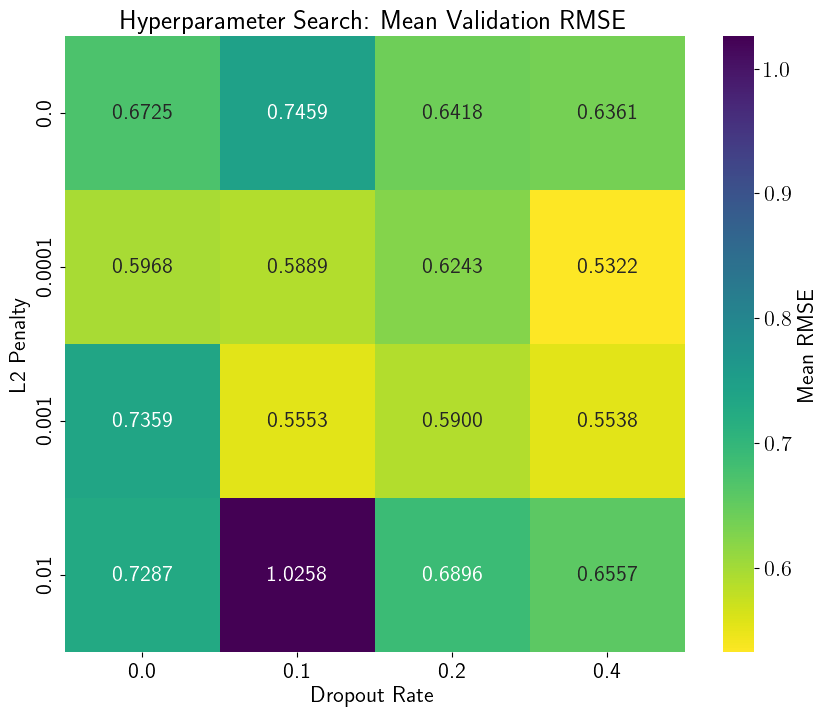

In [53]:
import seaborn as sns
# Assuming your 'evaluate_LSTM' function is in a file named utils_MLP.py
# from utils_MLP import evaluate_LSTM 

# --- 1. Define Hyperparameter Grids ---
# Define the different widths you want to test for each layer
dropouts = [0.0, 0.1, 0.2, 0.4]
l2_penalties = [0.0, 1e-4, 1e-3, 1e-2]

# Create an empty 2D array to store the error for each combination
# The rows will correspond to lstm_size, and columns to dense_size
error_grid_train = np.zeros((len(dropouts), len(l2_penalties)))
training_groups = {'All_CMIP7': scenarios_tier1.copy()}
# --- 2. Run the Evaluation Loop ---
print("Starting hyperparameter search...")

for i, dropout in enumerate(dropouts):
  for j, l2 in enumerate(l2_penalties):
    print(f"  Testing dropout rate: {dropout}, L2 penalty: {l2}")

    # --- Call your evaluation function with the current parameters ---
    # Replace with your actual data variables as needed.
    # This example uses the sample usage you provided.
    error_dict, _ = utils_MLP.evaluate_LSTM(
        train_scenarios=scenarios_tier1, 
        train_series=series_tier1,
        test_scenarios=scenarios_tier2, 
        test_series=series_tier2,
        agents=agents,
        training_groups=training_groups,
        n_lags=0,
        lstm_size=16,
        dense_size=32,
        dropout_rate=dropout,
        l2_penalty=l2
    )

    # --- 3. Process and Store the Results ---
    # The error_dict can have multiple training groups. We'll average the
    # errors across all test scenarios from all groups to get a single
    # representative error value for this parameter combination.
    all_errors = []
    for group_name in error_dict:
      for test_name in error_dict[group_name]:
        all_errors.append(error_dict[group_name][test_name])
    
    if not all_errors:
      print(f"    Warning: No errors were returned for this combination. Skipping.")
      mean_error = np.nan
    else:
      mean_error = np.mean(all_errors)
      print(f"    -> Mean RMSE: {mean_error:.4f}")

    error_grid_train[i, j] = mean_error

print("\nHyperparameter search complete.")

# --- 4. Plot the Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    error_grid_train,
    annot=True,         # Display the error values on the cells
    fmt=".4f",          # Format numbers to 4 decimal places
    cmap='viridis_r',   # Use a color map where lower is better (brighter)
    xticklabels=dropouts,
    yticklabels=l2_penalties,
    cbar_kws={'label': 'Mean RMSE'} # Label for the color bar
)

plt.xlabel("Dropout Rate")
plt.ylabel("L2 Penalty")
plt.title("Hyperparameter Search: Mean Validation RMSE")
plt.show()

In [113]:
# Create LSTM and evaluate on tier 2 experiments (training on multiple scenarios)
training_groups = {'Bracket':['H-ext','VLLO-ext']}
training_groups['All_CMIP7'] = scenarios_tier1.copy()
training_groups['noise'] = scenarios_opt.copy()

scenarios_tier1 += ['noise']
series_tier1.append((emis_dict_opt['noise'], delT_dict_opt['noise'], False))

error_dict_tier1_tier2_multi, yhat_dict_tier1_tier2_multi = utils_ML.evaluate_LSTM(scenarios_tier1, series_tier1, scenarios_tier2, series_tier2, agents, training_groups=training_groups, n_lags=0, lstm_size=16, dense_size=32, dropout_rate=0.1, l2_penalty=0.001)

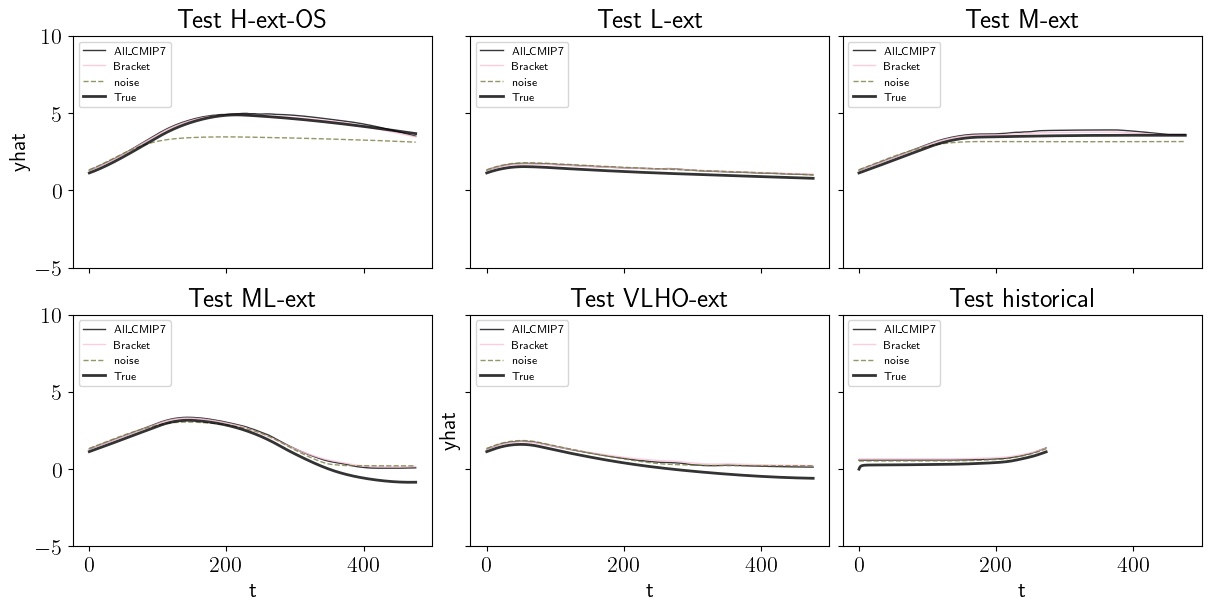

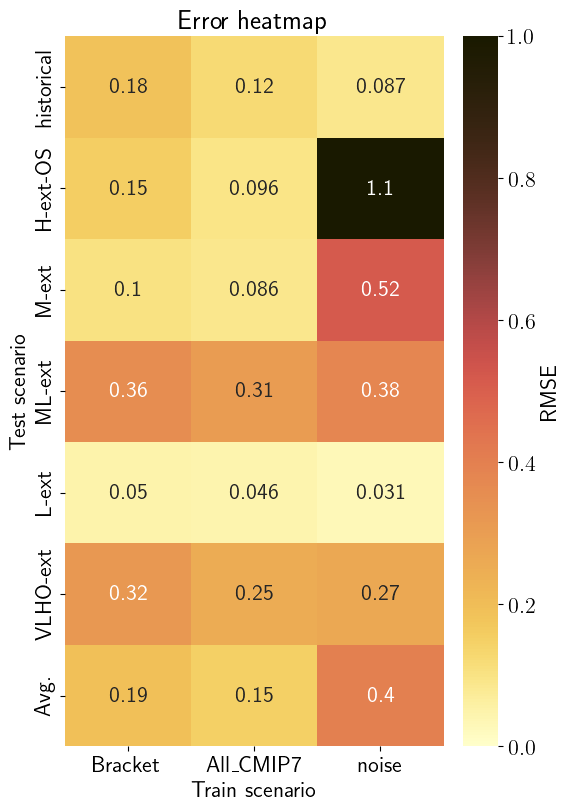

In [114]:
# Plot predictions and error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_ML.plot_yhats_grid(error_dict_tier1_tier2_multi, yhat_dict_tier1_tier2_multi, delT_dict_tier2)
utils_ML.plot_error_heatmap(error_dict_tier1_tier2_multi, scenarios_train_multi, scenarios_tier2)

#### 2. DECK for CMIP7, includes custom scenarios

In [115]:
# Generate DECK scenarios (includes custom scenarios e.g. abrupt-4xCH4)
agents = ['CO2']#,'CH4']#,'N2O','Sulfur','BC']
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())

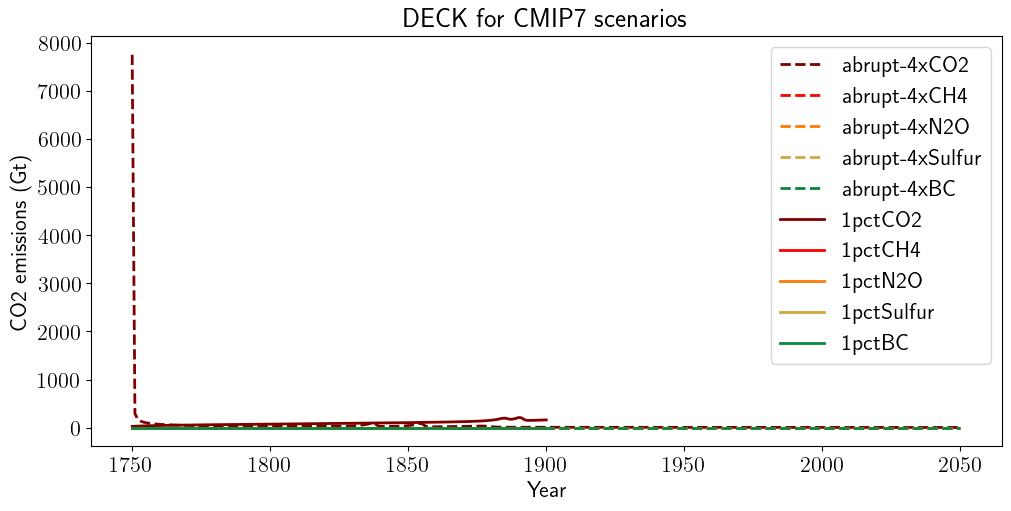

In [120]:
# Plot emissions scenarios (optional; sanity check, most emissions should = 0)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_DECK, agent, 'DECK for CMIP7', MIP='DECK')

In [117]:
# Run FaIR for each scenario to get temperature change
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')

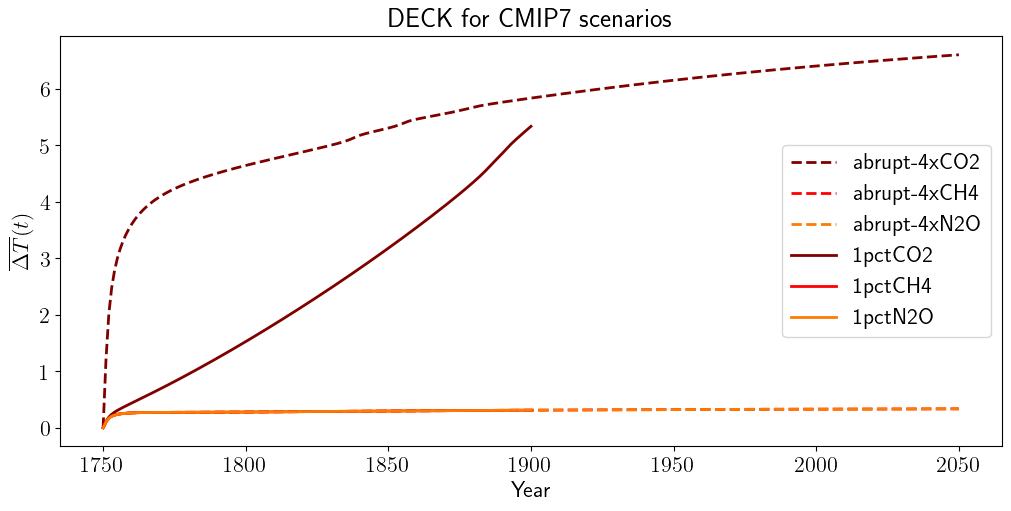

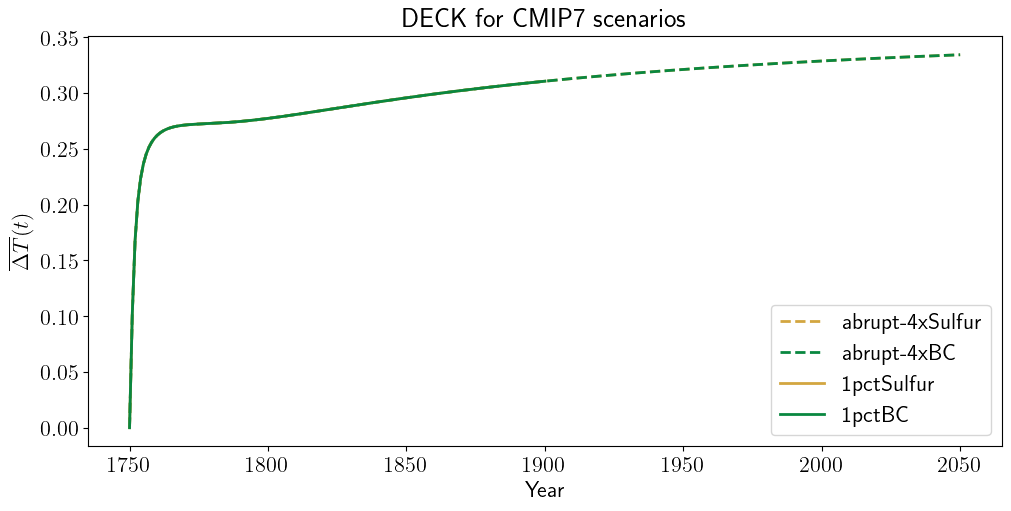

In [118]:
# Plot temperature change (optional)
well_mixed = ['abrupt-4xCO2','abrupt-4xCH4','abrupt-4xN2O',
              '1pctCO2','1pctCH4','1pctN2O']
aerosols = ['abrupt-4xSulfur','abrupt-4xBC',
            '1pctSulfur','1pctBC']
run_fair.plot_delT(delT_dict_DECK, well_mixed, 'DECK for CMIP7', MIP='DECK')
run_fair.plot_delT(delT_dict_DECK, aerosols, 'DECK for CMIP7', MIP='DECK')

In [59]:
# Evaluate MLP on DECK experiments (training on multiple scenarios)
scenarios_DECK_hist = scenarios_DECK.copy() + ['historical']
series_DECK_hist = []
for scen in scenarios_DECK:
  series_DECK_hist.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))
series_DECK_hist.append((emis_dict_tier1['historical'], delT_dict_tier1['historical'], False))
training_groups_DECK_hist = {'All_DECK': scenarios_DECK_hist.copy()}

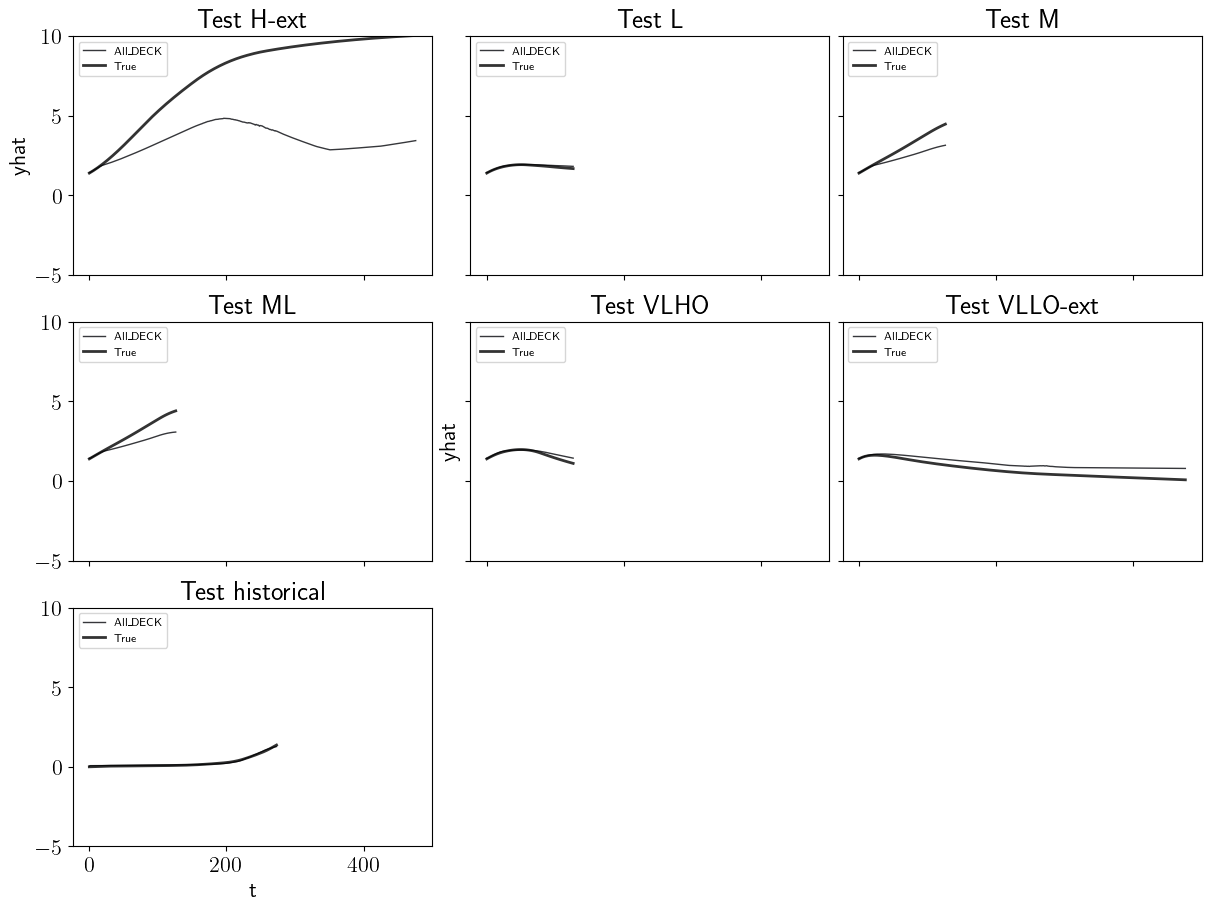

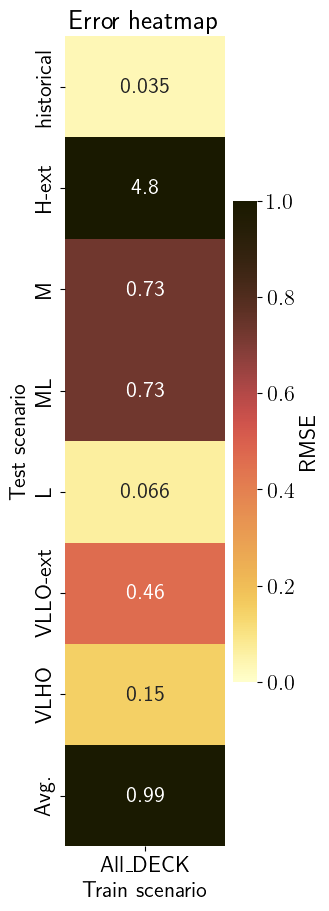

In [60]:
error_dict_DECK_hist_multi, yhat_dict_DECK_hist_multi = utils_MLP.evaluate_LSTM(scenarios_DECK_hist, series_DECK_hist, scenarios_tier1, series_tier1, agents, training_groups=training_groups_DECK_hist, n_lags=0, lstm_size=16, dense_size=32, dropout_rate=0.1, l2_penalty=0.001)
utils_MLP.plot_yhats_grid(error_dict_DECK_hist_multi, yhat_dict_DECK_hist_multi, delT_dict_tier1)
scenarios_train_DECK_hist = list(training_groups_DECK_hist.keys())
utils_MLP.plot_error_heatmap(error_dict_DECK_hist_multi, scenarios_train_DECK_hist, scenarios_tier1)

In [121]:
# Evaluate MLP on DECK experiments (training on multiple scenarios)
series_DECK = []
for scen in scenarios_DECK:
  series_DECK.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))

error_dict_DECK_multi, yhat_dict_DECK_multi = utils_ML.evaluate_LSTM(scenarios_tier1, series_tier1, scenarios_DECK, series_DECK, agents, training_groups=training_groups, n_lags=0, lstm_size=16, dense_size=32, dropout_rate=0.1, l2_penalty=0.001)

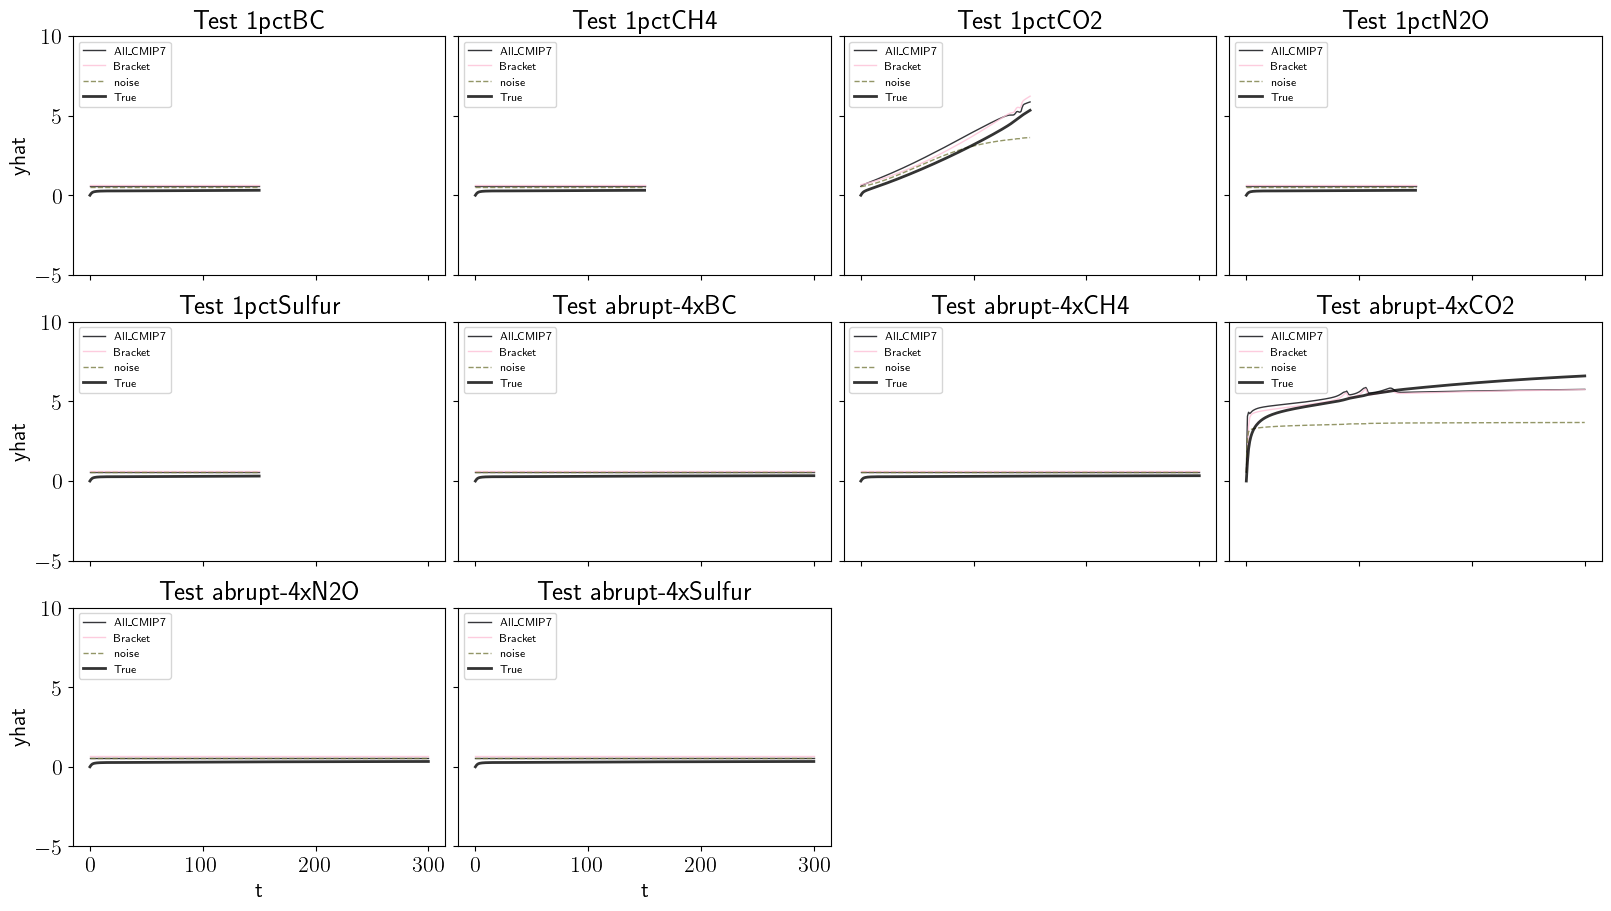

In [122]:
# Plot predictions (optional)
utils_ML.plot_yhats_grid(error_dict_DECK_multi, yhat_dict_DECK_multi, delT_dict_DECK)

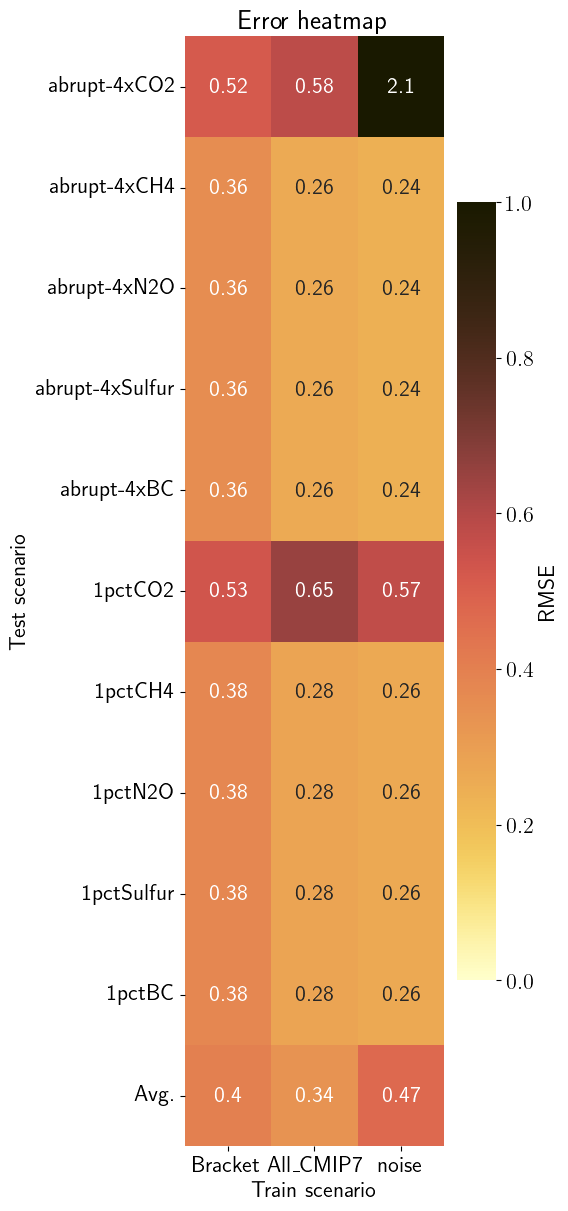

In [123]:
# Plot error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_ML.plot_error_heatmap(error_dict_DECK_multi, scenarios_train_multi, scenarios_DECK)

#### 3. GeoMIP for CMIP6

In [19]:
# Generate GeoMIP scenarios
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict_geoMIP = run_fair.load_geoMIP_CMIP6(agents, emis_dict_tier1)
scenarios_geoMIP = list(emis_dict_geoMIP.keys())

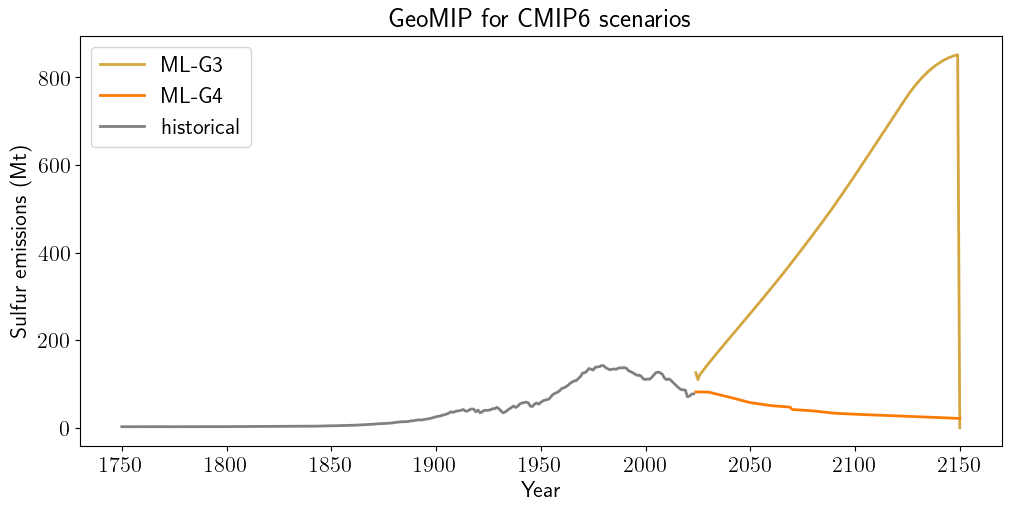

In [20]:
# Plot emissions scenarios (optional)
agent = 'Sulfur'
run_fair.plot_emissions(emis_dict_geoMIP, agent, 'GeoMIP for CMIP6', MIP='GeoMIP')

In [21]:
# Run FaIR for each scenario to get temperature change
delT_dict_geoMIP = run_fair.get_delT(emis_dict_geoMIP, scenarios_geoMIP, agents)

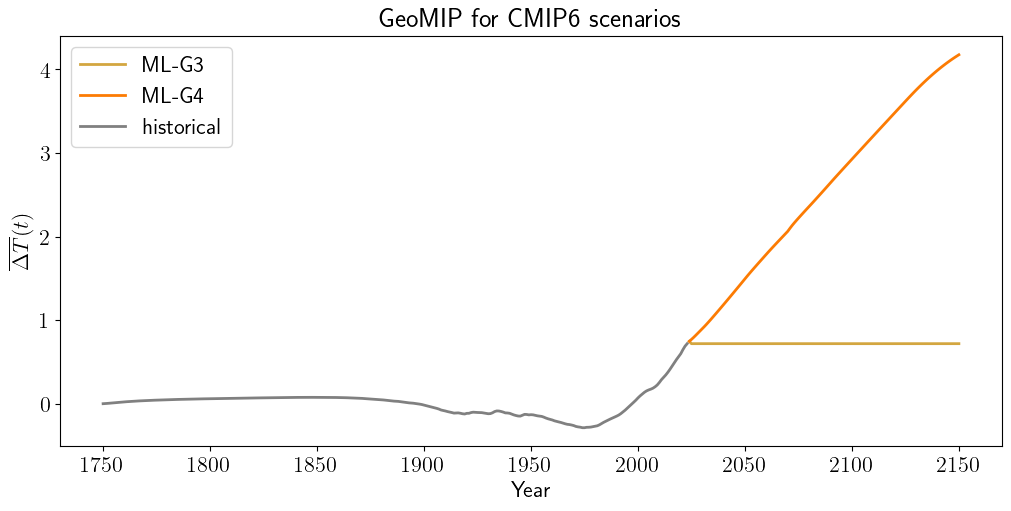

In [22]:
run_fair.plot_delT(delT_dict_geoMIP, scenarios_geoMIP, 'GeoMIP for CMIP6', MIP='GeoMIP')

In [63]:
series_geoMIP = []
for scen in scenarios_geoMIP:
  if scen != 'historical':
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], True))
  else:
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], False))

#error_dict_geoMIP_multi, yhat_dict_geoMIP_multi = utils_MLP.evaluate_trainsets_vs_tests_with_history(scenarios_tier1, series_tier1, scenarios_geoMIP, series_geoMIP, agents=agents, training_groups=training_groups, n_lags=150)
error_dict_geoMIP_multi, yhat_dict_geoMIP_multi = utils_ML.evaluate_LSTM(scenarios_tier1, series_tier1, scenarios_geoMIP, series_geoMIP, agents=agents, training_groups=training_groups, n_lags=0, lstm_size=16, dense_size=32, dropout_rate=0.1, l2_penalty=0.001)

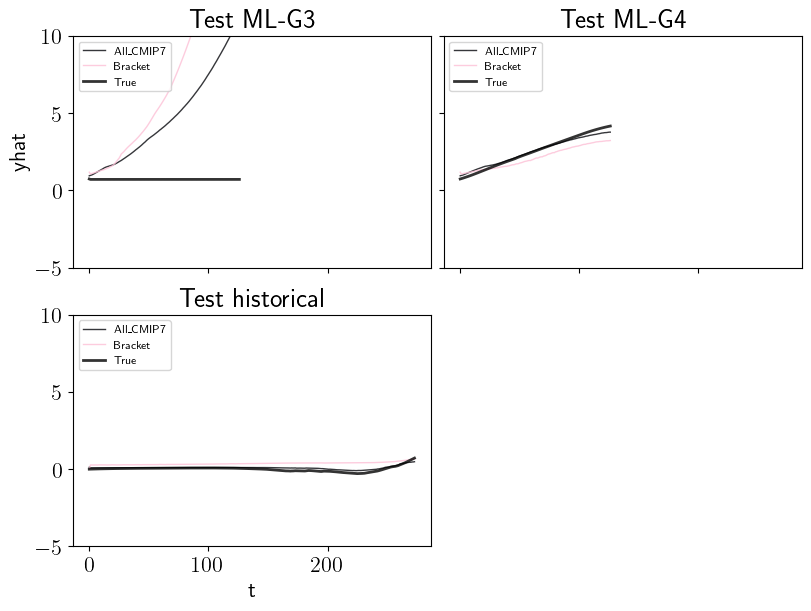

In [64]:
# Plot predictions (optional)
utils_ML.plot_yhats_grid(error_dict_geoMIP_multi, yhat_dict_geoMIP_multi, delT_dict_geoMIP)

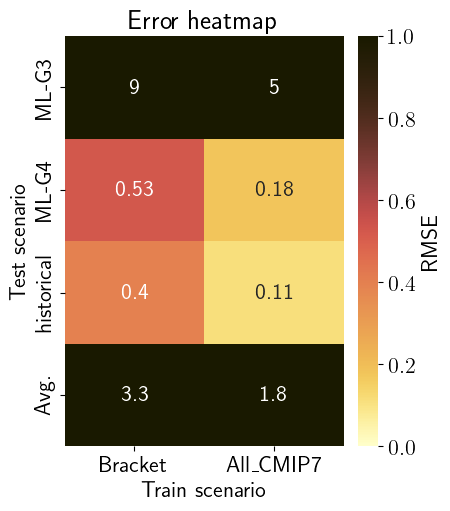

In [65]:
# Plot error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_ML.plot_error_heatmap(error_dict_geoMIP_multi, scenarios_train_multi, scenarios_geoMIP)

#### X. CDRMIP for CMIP6

#### X. DAMIP for CMIP6

#### X. Custom scenarios from the MIT Center for Sustainability Science and Strategy (CS3) - Current Trends (CT) and Accelerated Actions (AA)

In [124]:
# Generate CS3 scenarios
agents = ['CO2']#,'CH4','N2O','Sulfur','BC']
emis_dict_CS3 = run_fair.load_CS3(agents, emis_dict_tier1)
scenarios_CS3 = list(emis_dict_CS3.keys())

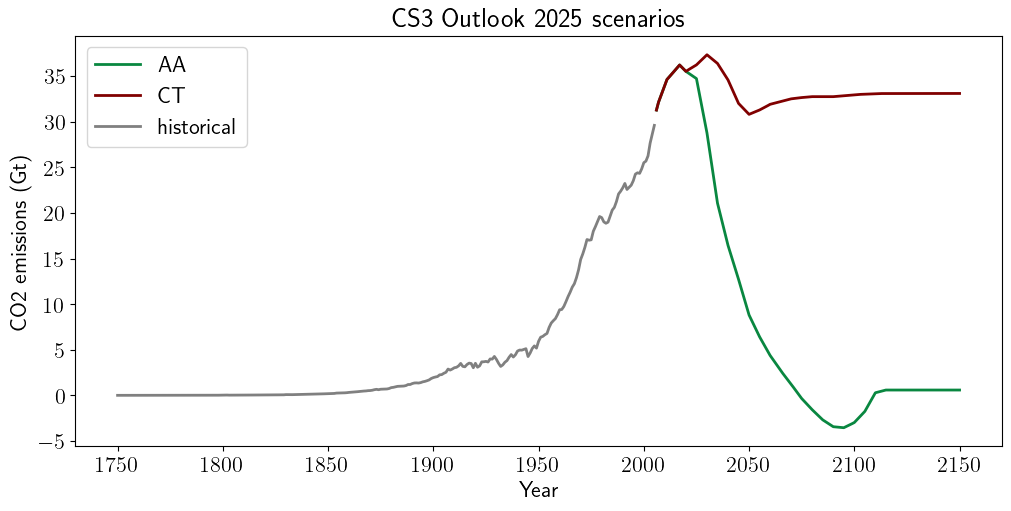

In [125]:
# Plot emissions scenarios (optional)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_CS3, agent, 'CS3 Outlook 2025', MIP='CS3')

In [126]:
# Run FaIR for each scenario to get temperature change
delT_dict_CS3 = run_fair.get_delT(emis_dict_CS3, scenarios_CS3, agents, MIP='CS3')

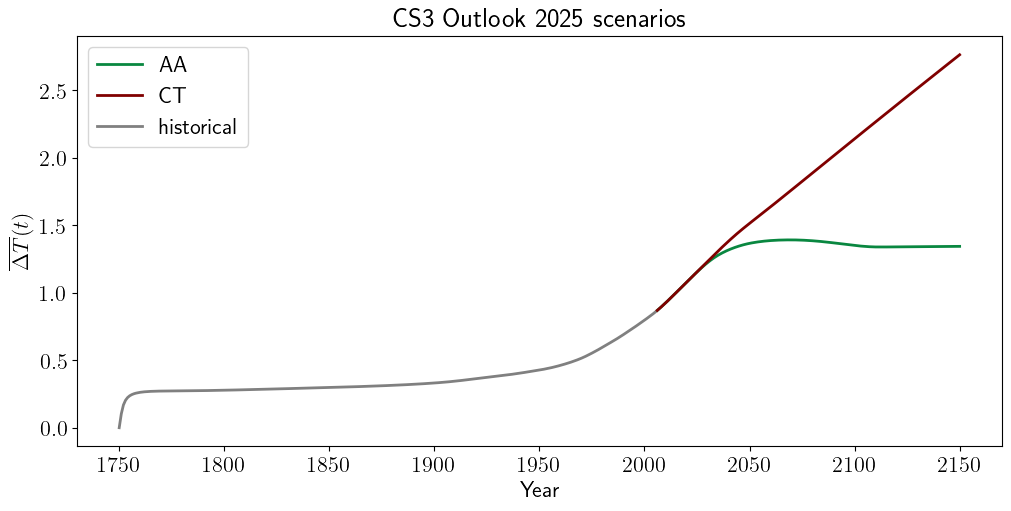

In [127]:
# Plot temperature change (optional)
run_fair.plot_delT(delT_dict_CS3, scenarios_CS3, 'CS3 Outlook 2025', MIP='CS3')

In [128]:
# Evaluate MLP on DECK experiments (training on multiple scenarios)
series_CS3 = []
for scen in scenarios_CS3:
  if scen != 'historical':
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], True))
  else:
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], False))

error_dict_CS3_multi, yhat_dict_CS3_multi = utils_ML.evaluate_LSTM(scenarios_tier1, series_tier1, scenarios_CS3, series_CS3, agents=agents, training_groups=training_groups, n_lags=0, lstm_size=16, dense_size=32, dropout_rate=0.1, l2_penalty=0.001)

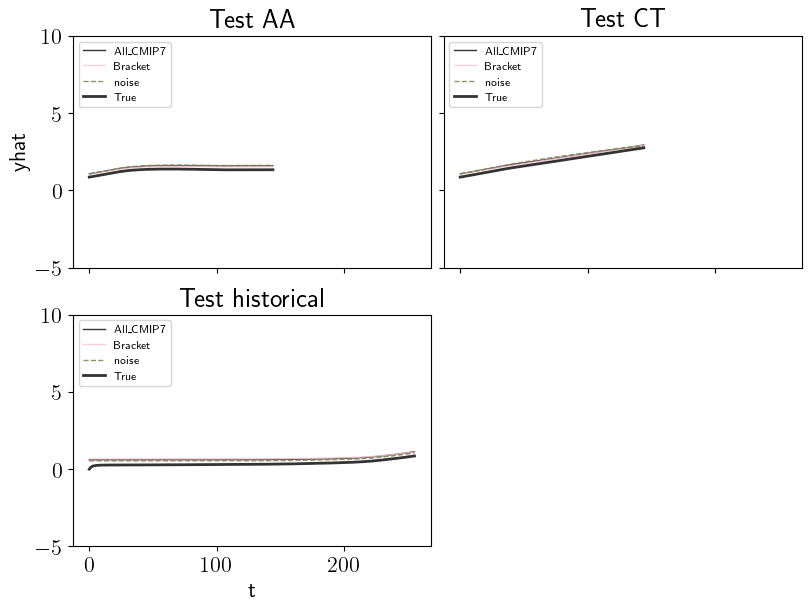

In [129]:
# Plot predictions (optional)
utils_ML.plot_yhats_grid(error_dict_CS3_multi, yhat_dict_CS3_multi, delT_dict_CS3)

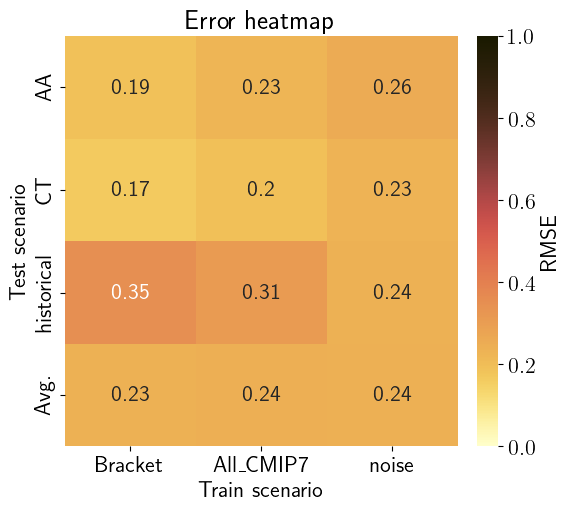

In [131]:
# Plot error heatmap (optional)
scenarios_train_multi = list(training_groups.keys())
utils_ML.plot_error_heatmap(error_dict_CS3_multi, scenarios_train_multi, scenarios_CS3)